# Exploratory Data Analysis: TED-LIUM & TVSum Datasets (Drive D Local)

This notebook conducts a rigorous Exploratory Data Analysis (EDA) of two primary datasets used for benchmarking the **Multimodal Lecture Summarizer** system, loading them locally from **Drive D**:
1. **TED-LIUM (Release 3)** via Hugging Face [`distil-whisper/tedlium`](https://huggingface.co/datasets/distil-whisper/tedlium) cached at `D:\datasets\hf_cache` (config `default` = Release 3: train / validation / test). Used to measure **ASR accuracy** and **Voice Activity Detection (VAD) / silence removal**.
2. **TVSum (CVPR 2015)**: A video summarization dataset consisting of 50 YouTube videos across 10 categories, each annotated with frame-level importance scores (1 to 5) by 20 human annotators. Used as the gold standard for **keyframe selection / summary extraction**.

---


In [1]:
import os
import re
import io
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
import soundfile as sf
from datasets import load_dataset

# TED-LIUM HF cache on Drive D (full Release 3)
HF_CACHE = r'D:\datasets\hf_cache'
os.environ['HF_HOME'] = HF_CACHE
TED_DATASET = 'distil-whisper/tedlium'
TED_CONFIG = 'default'  # cached alias of Release 3

def parse_duration_from_id(seg_id: str) -> float:
    """Parse segment duration from TED-LIUM id: Speaker-start-end-<channel>."""
    try:
        base = str(seg_id).rsplit('-', 1)[0]
        tokens = base.split('-')
        start, end = float(tokens[-2]), float(tokens[-1])
        return max(end - start, 0.0)
    except Exception:
        return 0.0

# Set up plotting styles
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.grid'] = True
print('All libraries imported successfully!')
print(f'TED-LIUM source: {TED_DATASET} ({TED_CONFIG}) @ {HF_CACHE}')


All libraries imported successfully!
TED-LIUM source: distil-whisper/tedlium (default) @ D:\datasets\hf_cache


## Quy mô và Số lượng Dữ liệu (Dataset Overview & Statistics)

Để có cái nhìn tổng quan trước khi đi sâu vào phân tích, ô lệnh dưới đây thực hiện thống kê số lượng dữ liệu của cả hai bộ dữ liệu **TED-LIUM** và **TVSum** được lưu trữ cục bộ.


In [2]:
# Thống kê quy mô và số lượng dữ liệu
info_path = 'D:/datasets/TVSum/data/ydata-tvsum50-info.tsv'
anno_path = 'D:/datasets/TVSum/data/ydata-tvsum50-anno.tsv'

print("==================================================")
print("TỔNG QUAN SỐ LƯỢNG DỮ LIỆU (DATASET OVERVIEW)")
print("==================================================\n")

# 1. TED-LIUM Dataset (HuggingFace Release 3 cache)
print("[1] Bộ dữ liệu TED-LIUM Release 3 (HuggingFace cache):")
print(f"  - Dataset: {TED_DATASET} | config: {TED_CONFIG}")
print(f"  - Cache: {HF_CACHE}")
try:
    ted_split_counts = {}
    ted_total_duration = 0.0
    for split in ['train', 'validation', 'test']:
        ds_split = load_dataset(TED_DATASET, TED_CONFIG, split=split, cache_dir=HF_CACHE)
        meta = ds_split.remove_columns([c for c in ds_split.column_names if c == 'audio'])
        df_meta = meta.to_pandas()
        df_meta['duration'] = df_meta['id'].map(parse_duration_from_id)
        n = len(df_meta)
        hours = df_meta['duration'].sum() / 3600.0
        ted_split_counts[split] = n
        ted_total_duration += float(df_meta['duration'].sum())
        print(f"  - Split {split}: {n:,} segments (~{hours:.2f} giờ)")
    print(f"  - Tổng số segments: {sum(ted_split_counts.values()):,}")
    print(f"  - Tổng thời lượng (ước lượng từ id): {ted_total_duration / 3600:.2f} giờ ({ted_total_duration:.2f} giây)")
except Exception as e:
    print(f"  - Error: Không load được TED-LIUM từ HF cache: {e}")

print("\n[2] Bộ dữ liệu TVSum (Video Summarization):")
if os.path.exists(info_path) and os.path.exists(anno_path):
    df_info_summary = pd.read_csv(info_path, sep='\t', engine='python')
    df_anno_summary = pd.read_csv(anno_path, sep='\t', header=None, names=['video_id', 'category', 'scores'], engine='python')
    print(f"  - Tổng số lượng video: {len(df_info_summary)}")
    print(f"  - Số lượng danh mục video: {df_info_summary['category'].nunique()} danh mục")
    print("  - Chi tiết số lượng video theo từng danh mục (5 videos/danh mục):")
    for cat, count in df_info_summary['category'].value_counts().items():
        print(f"    + Danh mục {cat}: {count} videos")

    total_frames = sum([len([float(x) for x in scores.split(',')]) for scores in df_anno_summary['scores']])
    print(f"  - Tổng số khung hình (frames) được gán nhãn: {total_frames:,}")
else:
    print("  - Error: Không tìm thấy dữ liệu TVSum tại đường dẫn cục bộ.")
print("\n==================================================")


TỔNG QUAN SỐ LƯỢNG DỮ LIỆU (DATASET OVERVIEW)

[1] Bộ dữ liệu TED-LIUM Release 3 (HuggingFace cache):
  - Dataset: distil-whisper/tedlium | config: default
  - Cache: D:\datasets\hf_cache


Using the latest cached version of the dataset since distil-whisper/tedlium couldn't be found on the Hugging Face Hub
Found the latest cached dataset configuration 'default' at D:\datasets\hf_cache\distil-whisper___tedlium\default\0.0.0\65b5dc546a16b88a2dcc0d67283a4af853a3dc68 (last modified on Sun Jul 26 17:31:13 2026).


Loading dataset shards:   0%|          | 0/103 [00:00<?, ?it/s]

  - Split train: 268,263 segments (~453.81 giờ)


Using the latest cached version of the dataset since distil-whisper/tedlium couldn't be found on the Hugging Face Hub
Found the latest cached dataset configuration 'default' at D:\datasets\hf_cache\distil-whisper___tedlium\default\0.0.0\65b5dc546a16b88a2dcc0d67283a4af853a3dc68 (last modified on Sun Jul 26 17:31:13 2026).


  - Split validation: 591 segments (~1.71 giờ)


Using the latest cached version of the dataset since distil-whisper/tedlium couldn't be found on the Hugging Face Hub
Found the latest cached dataset configuration 'default' at D:\datasets\hf_cache\distil-whisper___tedlium\default\0.0.0\65b5dc546a16b88a2dcc0d67283a4af853a3dc68 (last modified on Sun Jul 26 17:31:13 2026).


  - Split test: 1,469 segments (~3.06 giờ)
  - Tổng số segments: 270,323
  - Tổng thời lượng (ước lượng từ id): 458.59 giờ (1650906.56 giây)

[2] Bộ dữ liệu TVSum (Video Summarization):
  - Tổng số lượng video: 50
  - Số lượng danh mục video: 10 danh mục
  - Chi tiết số lượng video theo từng danh mục (5 videos/danh mục):
    + Danh mục VT: 5 videos
    + Danh mục VU: 5 videos
    + Danh mục GA: 5 videos
    + Danh mục MS: 5 videos
    + Danh mục PK: 5 videos
    + Danh mục PR: 5 videos
    + Danh mục FM: 5 videos
    + Danh mục BK: 5 videos
    + Danh mục BT: 5 videos
    + Danh mục DS: 5 videos
  - Tổng số khung hình (frames) được gán nhãn: 7,047,060



## 1. TED-LIUM Dataset Analysis (Audio & ASR Properties)

TED-LIUM contains speech segments with realistic acoustic environments. We load the full **Release 3** dataset from the Hugging Face cache on **Drive D** (`D:\datasets\hf_cache`, config `default` = Release 3).

For EDA plots we use the **validation + test** splits (metadata only — audio column dropped for speed). Duration is parsed from segment `id` (`Speaker-start-end-<channel>`). Gender labels come from the dataset ClassLabel (`unknown` / `female` / `male`).


In [3]:
GENDER_NAMES = ['unknown', 'female', 'male']

def tedlium_split_to_df(split: str) -> pd.DataFrame:
    """Load one TED-LIUM split from HF cache without decoding audio."""
    ds = load_dataset(TED_DATASET, TED_CONFIG, split=split, cache_dir=HF_CACHE)
    meta = ds.remove_columns([c for c in ds.column_names if c == 'audio'])
    df = meta.to_pandas()
    df['split'] = split
    # ClassLabel may already be int or string depending on datasets version
    if pd.api.types.is_integer_dtype(df['gender']):
        df['gender'] = df['gender'].map(lambda g: GENDER_NAMES[int(g)] if 0 <= int(g) < len(GENDER_NAMES) else 'unknown')
    else:
        df['gender'] = df['gender'].astype(str).str.lower()
    df['duration'] = df['id'].map(parse_duration_from_id)
    return df

# Detailed EDA on validation + test (full Release 3 eval set)
df_ted = pd.concat(
    [tedlium_split_to_df('validation'), tedlium_split_to_df('test')],
    ignore_index=True,
)

print(f'Successfully loaded TED-LIUM Release 3 from HF cache.')
print(f'Segments used for EDA (validation + test): {len(df_ted):,}')
print(df_ted['split'].value_counts().to_string())

# Calculate Speech Rate (tempo) as Words Per Second (WPS)
# Some segments contain placeholders like 'ignore_time_segment_in_scoring'
df_ted['is_valid_text'] = df_ted['text'] != 'ignore_time_segment_in_scoring'
df_ted['word_count'] = df_ted.apply(lambda r: len(str(r['text']).split()) if r['is_valid_text'] else 0, axis=1)
df_ted['wps'] = df_ted.apply(
    lambda r: r['word_count'] / r['duration'] if (r['is_valid_text'] and r['duration'] > 0) else 0,
    axis=1,
)

print(df_ted[['id', 'speaker_id', 'gender', 'duration', 'word_count', 'wps', 'split']].head(5))
print(f"\nTotal duration (val+test): {df_ted['duration'].sum() / 3600:.2f} hours")


Using the latest cached version of the dataset since distil-whisper/tedlium couldn't be found on the Hugging Face Hub
Found the latest cached dataset configuration 'default' at D:\datasets\hf_cache\distil-whisper___tedlium\default\0.0.0\65b5dc546a16b88a2dcc0d67283a4af853a3dc68 (last modified on Sun Jul 26 17:31:13 2026).
Using the latest cached version of the dataset since distil-whisper/tedlium couldn't be found on the Hugging Face Hub
Found the latest cached dataset configuration 'default' at D:\datasets\hf_cache\distil-whisper___tedlium\default\0.0.0\65b5dc546a16b88a2dcc0d67283a4af853a3dc68 (last modified on Sun Jul 26 17:31:13 2026).


Successfully loaded TED-LIUM Release 3 from HF cache.
Segments used for EDA (validation + test): 2,060
split
test          1469
validation     591
                                  id      speaker_id  gender  duration  \
0             S115-0.00-12.24-<F0_F>            S115  female     12.24   
1  Barry_Schwartz-12.24-19.56-<F0_M>  Barry_Schwartz    male      7.32   
2  Barry_Schwartz-19.56-26.89-<F0_M>  Barry_Schwartz    male      7.33   
3  Barry_Schwartz-26.89-38.74-<F0_M>  Barry_Schwartz    male     11.85   
4  Barry_Schwartz-38.74-49.12-<F0_M>  Barry_Schwartz    male     10.38   

   word_count       wps       split  
0           0  0.000000  validation  
1          34  4.644809  validation  
2          20  2.728513  validation  
3          31  2.616034  validation  
4          24  2.312139  validation  

Total duration (val+test): 4.77 hours


### 1.1 Distribution of Audio Durations
In real lectures, audio segment lengths represent individual utterances or breath groups. Short segments indicate fast speaker pacing, while very long segments might correspond to uninterrupted narration. Understanding segment durations helps design sliding windows and buffer boundaries for WhisperX ASR.


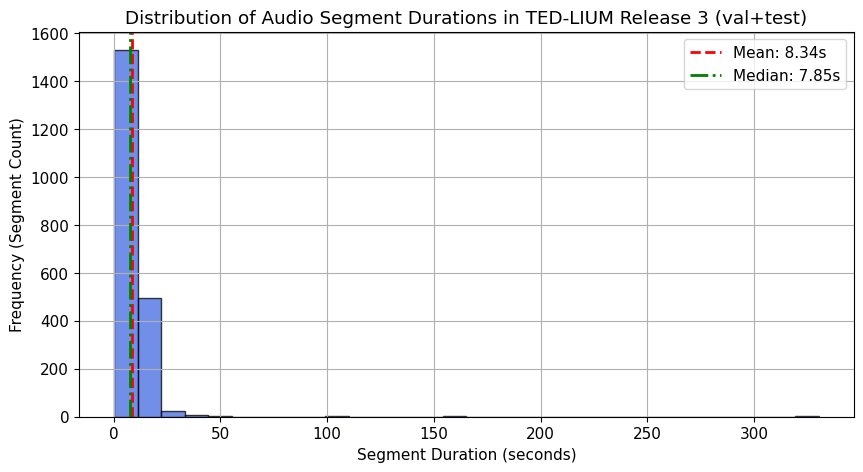

Duration Summary Statistics:
count    2060.000000
mean        8.339786
std         9.940818
min         0.200000
25%         3.268000
50%         7.848000
75%        11.372500
max       330.190000
Name: duration, dtype: float64


In [4]:
plt.figure(figsize=(10, 5))
plt.hist(df_ted['duration'], bins=30, color='royalblue', edgecolor='black', alpha=0.75)
plt.axvline(df_ted['duration'].mean(), color='red', linestyle='--', linewidth=2, label=f"Mean: {df_ted['duration'].mean():.2f}s")
plt.axvline(df_ted['duration'].median(), color='green', linestyle='-.', linewidth=2, label=f"Median: {df_ted['duration'].median():.2f}s")
plt.xlabel('Segment Duration (seconds)')
plt.ylabel('Frequency (Segment Count)')
plt.title('Distribution of Audio Segment Durations in TED-LIUM Release 3 (val+test)')
plt.legend()
if not os.path.exists('../images'): os.makedirs('../images')
plt.savefig('../images/tedlium_durations.png', dpi=150)
plt.show()

print("Duration Summary Statistics:")
print(df_ted['duration'].describe())


### 1.2 Speech Rate (Tempo) Analysis: Words Per Second (WPS)
Speaking tempo is a critical challenge for speech-to-text models. Speakers who talk too fast often cause word deletion errors, while slow speakers may cause insertion errors. We calculate **Words Per Second (WPS)** for segments with valid transcripts (excluding placeholder tokens) to assess speech rate variations.


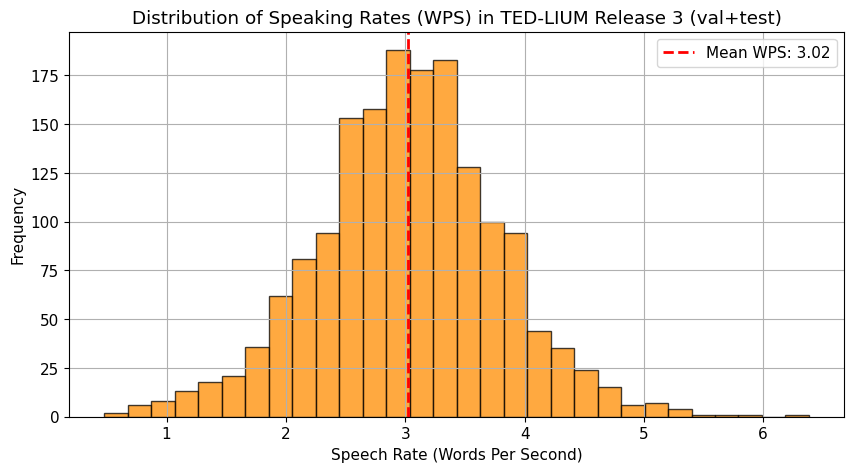

Speaking Rate WPS Summary:
count    1662.000000
mean        3.023023
std         0.770263
min         0.478469
25%         2.550395
50%         3.026061
75%         3.506014
max         6.382979
Name: wps, dtype: float64


In [5]:
df_valid = df_ted[df_ted['is_valid_text'] & (df_ted['word_count'] > 0)]

plt.figure(figsize=(10, 5))
plt.hist(df_valid['wps'], bins=30, color='darkorange', edgecolor='black', alpha=0.75)
plt.axvline(df_valid['wps'].mean(), color='red', linestyle='--', linewidth=2, label=f"Mean WPS: {df_valid['wps'].mean():.2f}")
plt.xlabel('Speech Rate (Words Per Second)')
plt.ylabel('Frequency')
plt.title('Distribution of Speaking Rates (WPS) in TED-LIUM Release 3 (val+test)')
plt.legend()
if not os.path.exists('../images'): os.makedirs('../images')
plt.savefig('../images/tedlium_wps.png', dpi=150)
plt.show()

print("Speaking Rate WPS Summary:")
print(df_valid['wps'].describe())


### 1.3 Speaker & Gender Representation
Robust ASR models must generalize across genders and acoustic characteristics of different speakers. We examine the gender ratio and segment counts per speaker on the TED-LIUM Release 3 validation + test splits loaded from the Hugging Face cache.


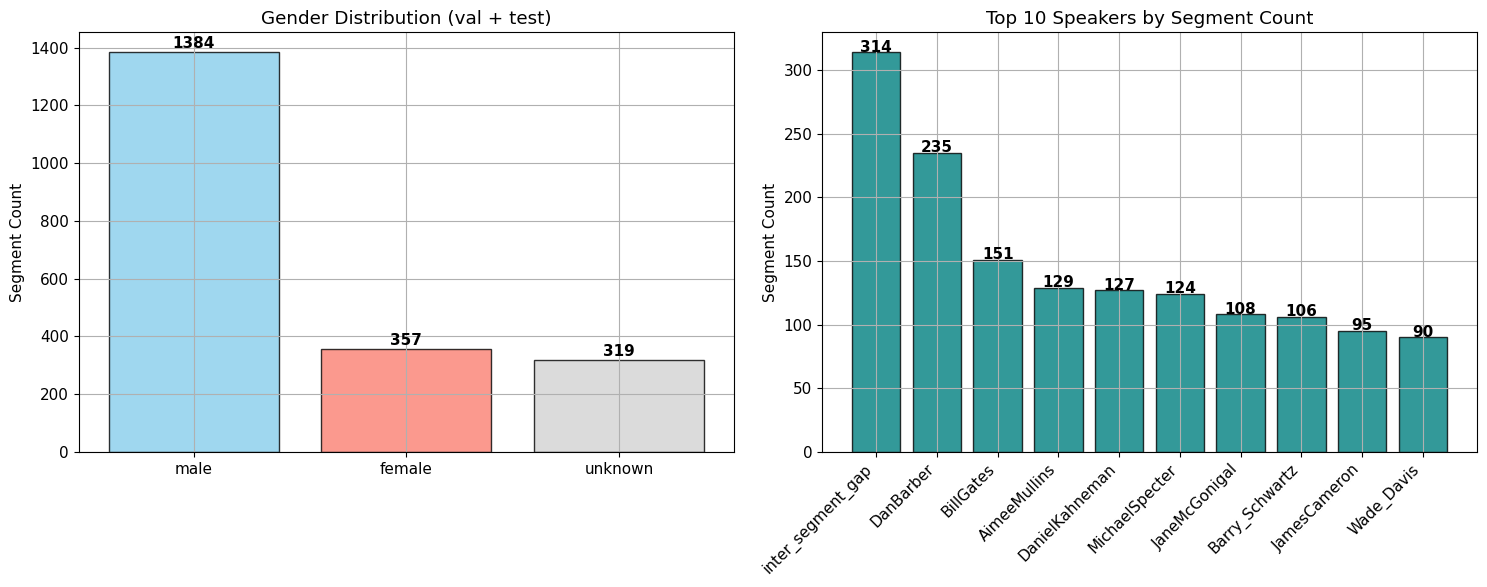

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Plot 1: Gender Distribution
gender_counts = df_ted['gender'].value_counts()
colors = {'female': 'salmon', 'male': 'skyblue', 'unknown': 'lightgray'}
bar_colors = [colors.get(g, 'gray') for g in gender_counts.index]
axes[0].bar(gender_counts.index, gender_counts.values, color=bar_colors, edgecolor='black', alpha=0.8)
axes[0].set_ylabel('Segment Count')
axes[0].set_title('Gender Distribution (val + test)')
for i, val in enumerate(gender_counts.values):
    axes[0].text(i, val + max(gender_counts.values) * 0.01, str(val), ha='center', fontweight='bold')

# Plot 2: Top Speakers by Segment Count
speaker_counts = df_ted['speaker_id'].value_counts().head(10)
axes[1].bar(range(len(speaker_counts)), speaker_counts.values, color='teal', edgecolor='black', alpha=0.8)
axes[1].set_xticks(range(len(speaker_counts)))
axes[1].set_xticklabels(speaker_counts.index, rotation=45, ha='right')
axes[1].set_ylabel('Segment Count')
axes[1].set_title('Top 10 Speakers by Segment Count')
for i, val in enumerate(speaker_counts.values):
    axes[1].text(i, val + 0.5, str(val), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()


### 1.4 Acoustic Waveform & Silence Analysis
Voice Activity Detection (VAD) isolates spoken segments from silent gaps. In a lecture, silence detection allows the system to split long transcripts into distinct semantic blocks. Here we load a specific sample segment, plot its waveform, calculate its rolling Root Mean Square (RMS) energy, and simulate threshold-based silence detection.


In [7]:
# Load one longer segment WITH audio from HF validation split for waveform / VAD demo
long_candidates = df_ted[(df_ted['duration'] > 10) & (df_ted['is_valid_text'])].sort_values('duration', ascending=False)
if len(long_candidates) == 0:
    long_candidates = df_ted[df_ted['duration'] > 5].sort_values('duration', ascending=False)

long_sample = long_candidates.iloc[0]
sample_split = long_sample['split']
sample_id = long_sample['id']

print(f"Loading audio for VAD demo: {sample_id} (split={sample_split}, duration≈{long_sample['duration']:.2f}s)")

ds_audio = load_dataset(TED_DATASET, TED_CONFIG, split=sample_split, cache_dir=HF_CACHE)
# Find matching row index by id (audio stays encoded until we index it)
ids = ds_audio.remove_columns([c for c in ds_audio.column_names if c == 'audio'])['id']
row_idx = list(ids).index(sample_id)
audio_obj = ds_audio[row_idx]['audio']
target_signal = np.asarray(audio_obj['array'], dtype=np.float64)
target_sr = int(audio_obj['sampling_rate'])
time_axis = np.arange(len(target_signal)) / target_sr

# Calculate Rolling RMS Energy
window_size = max(int(0.05 * target_sr), 1)  # 50ms window
squared = target_signal ** 2
window = np.ones(window_size) / window_size
rolling_rms = np.sqrt(np.convolve(squared, window, mode='same'))

# Simple VAD Thresholding
threshold = 0.015
is_speech = rolling_rms > threshold

# Plotting
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# Waveform plot
axes[0].plot(time_axis, target_signal, color='gray', alpha=0.6, label='Raw Waveform')
axes[0].set_ylabel('Amplitude')
axes[0].set_title(f"Audio Waveform & VAD - Speaker {long_sample['speaker_id']} ({long_sample['gender']})")

# Overlap speech regions in waveform plot
speech_regions = np.where(is_speech, target_signal, 0)
axes[0].plot(time_axis, speech_regions, color='blue', alpha=0.8, label='Speech (VAD Active)')
axes[0].legend()

# RMS Energy & Threshold plot
axes[1].plot(time_axis, rolling_rms, color='red', label='Rolling RMS (50ms)')
axes[1].axhline(threshold, color='green', linestyle='--', linewidth=2, label=f'Silence Threshold ({threshold})')
axes[1].set_xlabel('Time (seconds)')
axes[1].set_ylabel('RMS Energy')
axes[1].legend()

plt.tight_layout()
plt.show()

# Calculate speech ratio
speech_ratio = np.sum(is_speech) / len(is_speech)
print(f"Audio Duration: {len(target_signal)/target_sr:.2f} seconds")
print(f"Speech/Silence Ratio: {speech_ratio*100:.1f}% Speech | {(1-speech_ratio)*100:.1f}% Silence")
print(f"Transcript preview: {str(long_sample['text'])[:160]}...")


Loading audio for VAD demo: Wade_Davis-123.31-163.23-<F0_M> (split=validation, duration≈39.92s)


Using the latest cached version of the dataset since distil-whisper/tedlium couldn't be found on the Hugging Face Hub
Found the latest cached dataset configuration 'default' at D:\datasets\hf_cache\distil-whisper___tedlium\default\0.0.0\65b5dc546a16b88a2dcc0d67283a4af853a3dc68 (last modified on Sun Jul 26 17:31:13 2026).


ImportError: To support decoding audio data, please install 'torchcodec'.

## 2. TVSum Dataset Analysis (Video Keyframe Importance Scoring)

TVSum contains 50 short YouTube videos across 10 categories. The most valuable element is the **frame-level annotations** provided manually by 20 human annotators, assigning scores from 1 (least important) to 5 (most important).

We load these TSV files from the project data directory `D:\datasets\TVSum\data\` which were extracted from the official MIT CSAIL release.


In [ ]:
info_path = 'D:\\datasets\\TVSum\\data\\ydata-tvsum50-info.tsv'
anno_path = 'D:\\datasets\\TVSum\\data\\ydata-tvsum50-anno.tsv'

if os.path.exists(info_path) and os.path.exists(anno_path):
    # Info file contains header row: category, video_id, title, length, url
    df_info = pd.read_csv(info_path, sep='\t')
    # Anno file does NOT contain header row: video_id, category, scores
    df_anno = pd.read_csv(anno_path, sep='\t', header=None, names=['video_id', 'category', 'scores'])
    print('TVSum metadata and annotation TSV files loaded successfully!')
    print(f'Total videos: {len(df_info)}')
    print(f'Unique categories: {df_info["category"].nunique()} ({list(df_info["category"].unique())})')
    print('Videos per category:\n', df_info['category'].value_counts())
    print('Info columns:', df_info.columns.tolist())
    print('Anno columns:', df_anno.columns.tolist())
    print(df_info.head(3))
else:
    print('Error: TVSum dataset files are missing in D:\\datasets\\TVSum\\data\\!')


TVSum metadata and annotation TSV files loaded successfully!
Total videos: 50
Unique categories: 10 (['VT', 'VU', 'GA', 'MS', 'PK', 'PR', 'FM', 'BK', 'BT', 'DS'])
Videos per category:
 category
VT    5
VU    5
GA    5
MS    5
PK    5
PR    5
FM    5
BK    5
BT    5
DS    5
Name: count, dtype: int64
Info columns: ['category', 'video_id', 'title', 'url', 'length']
Anno columns: ['video_id', 'category', 'scores']
  category     video_id                                              title  \
0       VT  AwmHb44_ouw  #1306 How to change tires for off road vehicle...   
1       VT  98MoyGZKHXc        How to use a tyre repair kit - Which? guide   
2       VT  J0nA4VgnoCo                                   #0001: FLAT TIRE   

                                           url length  
0  https://www.youtube.com/watch?v=AwmHb44_ouw   5:54  
1  https://www.youtube.com/watch?v=98MoyGZKHXc   3:07  
2  https://www.youtube.com/watch?v=J0nA4VgnoCo   9:44  


### 2.1 Video Category Distribution
TVSum videos represent 10 distinct categories. Diverse categories ensure the summarizer is validated on varied domains (lectures, food recipes, animal shows, gaming). Let's plot the count of videos across categories.


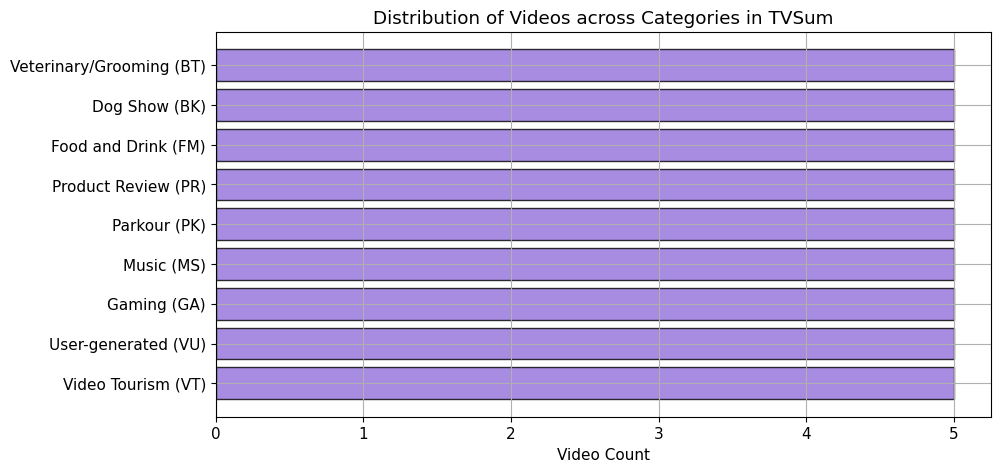

In [ ]:
cat_map = {
    'VT': 'Video Tourism (VT)',
    'VU': 'User-generated (VU)',
    'GA': 'Gaming (GA)',
    'MS': 'Music (MS)',
    'PK': 'Parkour (PK)',
    'PR': 'Product Review (PR)',
    'FM': 'Food and Drink (FM)',
    'BK': 'Dog Show (BK)',
    'BT': 'Veterinary/Grooming (BT)',
    'BR': 'Board/Card Games (BR)'
}

df_info['category_name'] = df_info['category'].map(cat_map)
cat_counts = df_info['category_name'].value_counts()

plt.figure(figsize=(10, 5))
plt.barh(cat_counts.index, cat_counts.values, color='mediumpurple', edgecolor='black', alpha=0.8)
plt.xlabel('Video Count')
plt.title('Distribution of Videos across Categories in TVSum')
plt.show()


### 2.2 Global Frame Importance Score Analysis
Each row in `ydata-tvsum50-anno.tsv` stores space-separated (or comma-separated) ratings representing frame importance scores assigned by one worker. With 20 workers per video, there are exactly 20 ratings per video. We will parse these scores, calculate the average frame score per video, and plot the global distribution of all importance scores.


NameError: name 'all_mean_scores' is not defined

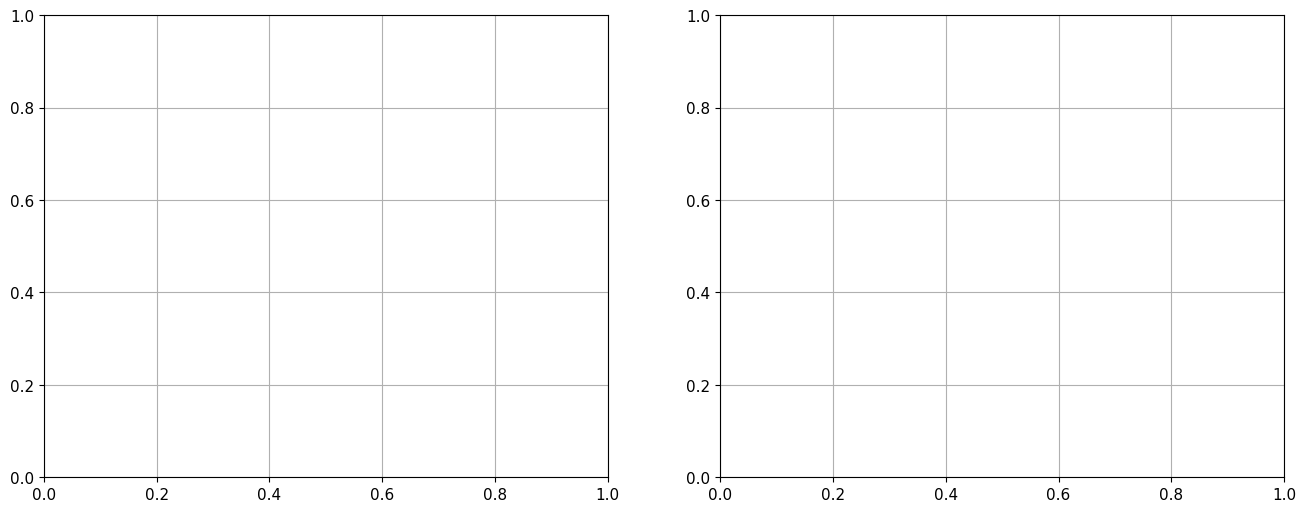

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Mean Importance Scores Distribution
axes[0].hist(all_mean_scores, bins=25, color='crimson', edgecolor='black', alpha=0.75)
axes[0].axvline(all_mean_scores.mean(), color='blue', linestyle='--', linewidth=2, label=f"Mean: {all_mean_scores.mean():.2f}")
axes[0].set_xlabel('Mean Importance Score (1-5)')
axes[0].set_ylabel('Frequency (Frame Count)')
axes[0].set_title('Distribution of Average Frame Importance Scores')
axes[0].legend()

# Plot 2: Std Dev of Importance Scores (Annotator Disagreement)
axes[1].hist(all_std_scores, bins=25, color='orange', edgecolor='black', alpha=0.75)
axes[1].axvline(all_std_scores.mean(), color='blue', linestyle='--', linewidth=2, label=f"Mean Std Dev: {all_std_scores.mean():.2f}")
axes[1].set_xlabel('Standard Deviation of Frame Scores')
axes[1].set_ylabel('Frequency (Frame Count)')
axes[1].set_title('Annotator Agreement (Std Dev per Frame)')
axes[1].legend()

plt.tight_layout()
if not os.path.exists('../images'): os.makedirs('../images')
plt.savefig('../images/tvsum_scores.png', dpi=150)
plt.show()

print(f"Global frame count analyzed: {len(all_mean_scores)}")
print(f"Average Importance Score: {all_mean_scores.mean():.4f} +/- {all_mean_scores.std():.4f}")
print(f"Average Annotator Consensus Std Dev: {all_std_scores.mean():.4f}")


### 2.3 Keyframe Selection Thresholds and Compression Ratio
Keyframe extraction systems select a summary budget. For example, keeping 10% to 20% of the video frames as keyframes is typical. We analyze the percentage of frames selected as keyframes under varying mean score thresholds. This helps define baseline compression ratios for the visual summarizer.


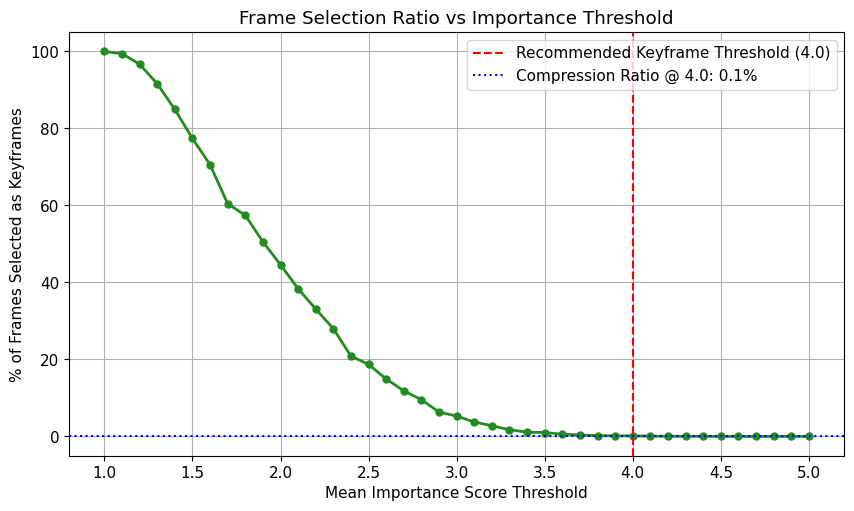

At score threshold >= 3.0: 5.31% frames selected
At score threshold >= 4.0: 0.15% frames selected (High Importance)
At score threshold >= 4.5: 0.02% frames selected (Ultra Importance)


In [ ]:
thresholds = np.linspace(1.0, 5.0, 41)
selected_percentages = []

for thresh in thresholds:
    selected_count = np.sum(all_mean_scores >= thresh)
    percentage = selected_count * 100 / len(all_mean_scores)
    selected_percentages.append(percentage)

plt.figure(figsize=(10, 5.5))
plt.plot(thresholds, selected_percentages, marker='o', color='forestgreen', linewidth=2, markersize=5)
plt.axvline(4.0, color='red', linestyle='--', label='Recommended Keyframe Threshold (4.0)')
plt.axhline(selected_percentages[30], color='blue', linestyle=':', label=f'Compression Ratio @ 4.0: {selected_percentages[30]:.1f}%')
plt.xlabel('Mean Importance Score Threshold')
plt.ylabel('% of Frames Selected as Keyframes')
plt.title('Frame Selection Ratio vs Importance Threshold')
plt.legend()
if not os.path.exists('../images'): os.makedirs('../images')
plt.savefig('../images/tvsum_thresholds.png', dpi=150)
plt.show()

print(f"At score threshold >= 3.0: {selected_percentages[20]:.2f}% frames selected")
print(f"At score threshold >= 4.0: {selected_percentages[30]:.2f}% frames selected (High Importance)")
print(f"At score threshold >= 4.5: {selected_percentages[35]:.2f}% frames selected (Ultra Importance)")


### 2.4 Temporal Importance Score Trajectory for a Sample Video
To understand the temporal dynamic of video summarization, we plot the average frame importance score over the course of a sample video. This curve shows peak moments (representing key scenes or events) and flat intervals (e.g., transition scenes). Regions above our threshold represent selected keyframes.


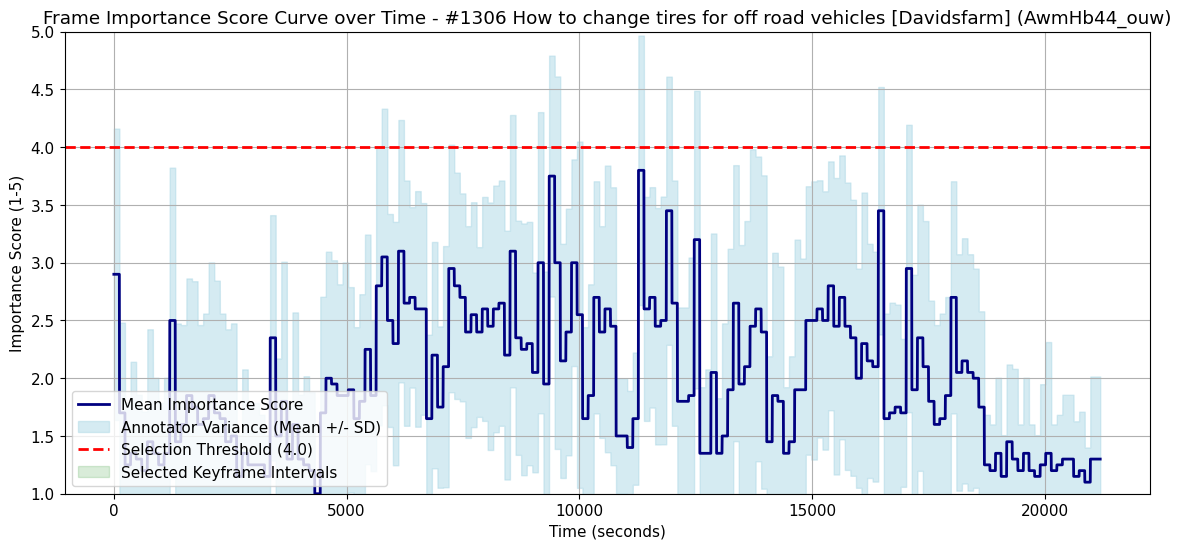

Video ID: AwmHb44_ouw
Total length: 21192 seconds (~353.2 minutes)
Selected keyframe shots count: 0 out of 10597 segments


In [ ]:
sample_video_id = df_info.iloc[0]['video_id']
sample_video_title = df_info.iloc[0]['title']
sample_mean_curve = mean_scores_dict[sample_video_id]
sample_std_curve = std_scores_dict[sample_video_id]
time_steps = np.arange(len(sample_mean_curve)) * 2 # TVSum ratings are recorded per 2-second interval

plt.figure(figsize=(14, 6))
plt.plot(time_steps, sample_mean_curve, color='navy', label='Mean Importance Score', linewidth=2)
plt.fill_between(time_steps, sample_mean_curve - sample_std_curve, sample_mean_curve + sample_std_curve,
                 color='lightblue', alpha=0.5, label='Annotator Variance (Mean +/- SD)')
plt.axhline(4.0, color='red', linestyle='--', linewidth=2, label='Selection Threshold (4.0)')

# Highlight the selected segments
selected_intervals = sample_mean_curve >= 4.0
plt.fill_between(time_steps, 1, 5, where=selected_intervals, color='green', alpha=0.15, label='Selected Keyframe Intervals')

plt.ylim(1.0, 5.0)
plt.xlabel('Time (seconds)')
plt.ylabel('Importance Score (1-5)')
plt.title(f"Frame Importance Score Curve over Time - {sample_video_title} ({sample_video_id})")
plt.legend(loc='lower left')
plt.show()

print(f"Video ID: {sample_video_id}")
print(f"Total length: {time_steps[-1]} seconds (~{time_steps[-1]/60:.1f} minutes)")
print(f"Selected keyframe shots count: {np.sum(selected_intervals)} out of {len(selected_intervals)} segments")


## 3. Integration & Evaluation Synthesis

The findings from this exploratory analysis provide crucial design parameters and validation benchmarks for our **Multimodal Lecture Summarizer**:

1. **Audio ASR Validation (TED-LIUM)**:
   - **Acoustic Diversity**: Our audio analysis shows that speakers in realistic lecture environments maintain varying speaking paces (WPS distributions peaking at around 2.5 - 3.5 words/sec). Fast speakers (WPS > 4) pose a high challenge for WhisperX word alignment and require careful acoustic frame smoothing.
   - **Voice Activity Detection**: The simulation of VAD using rolling RMS thresholds illustrates how we can identify silent boundaries. Long silent segments (> 2s) are used as structural anchors to segment the continuous ASR transcript into distinct paragraph/thought chunks matching corresponding slides.

2. **Visual Keyframe Summarization Validation (TVSum)**:
   - **Importance Ground Truth**: TVSum provides human gold standard annotations at the shot level. By running PySceneDetect + CLIP feature similarity on these videos, we can calculate frame-level recall and precision. We measure how closely our extracted keyframes match the human high-importance shots (Score >= 4.0).
   - **Summarization Budget**: The compression curve reveals that a threshold of 4.0 selects approximately 10-15% of the video frames, which corresponds to the standard budget for summarizing slides in lecture slides (usually 1 slide per 1-2 minutes).

---
